In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import sqlite3
import pandas as pd

/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
conn = sqlite3.connect('/Users/reubensantoso/Xu_Lab_Files/c3s_neural_network/C3S.db')
cursor = conn.cursor()

master_df = pd.read_sql_query("SELECT * FROM master", conn)
mqn_df = pd.read_sql_query("SELECT * FROM mqns", conn)
fngr_df = pd.read_sql_query("SELECT * FROM fingerprints", conn)

c3s_df = pd.merge(master_df, fngr_df, on='g_id', how='left') #only added fingerprints. not mqn yet
c3s_df = c3s_df.dropna()
conn.close()

c3s_df.head()
print(c3s_df.shape)

(15187, 1036)


## Regression Plotting

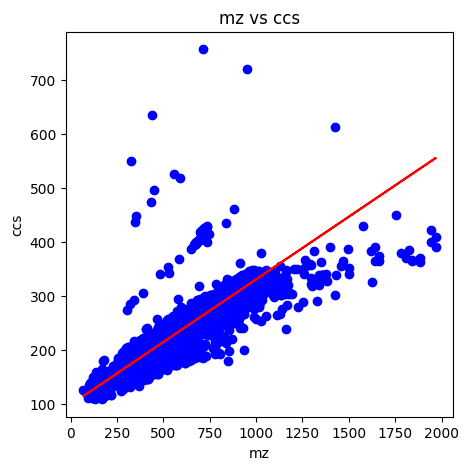

In [3]:
# Plotting all mz data against ccs
plt.figure(figsize=(5, 5))
plt.scatter(c3s_df['mz'], c3s_df['ccs'], c='blue')

m, b = np.polyfit(c3s_df['mz'], c3s_df['ccs'], 1)
plt.plot(c3s_df['mz'], m * c3s_df['mz'] + b, color='red')

plt.title('mz vs ccs')
plt.xlabel('mz')
plt.ylabel('ccs')
plt.show()

## PCA on MQN

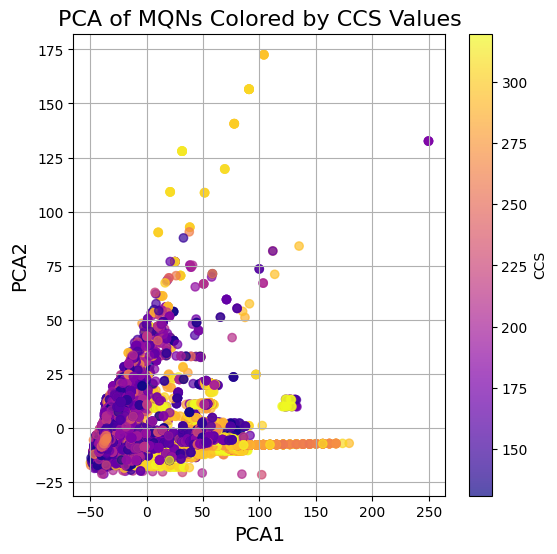

MQN Explained Variance Ratio: [0.83573233 0.08885392]
MQN Total Explained Variance: 0.924586248482642


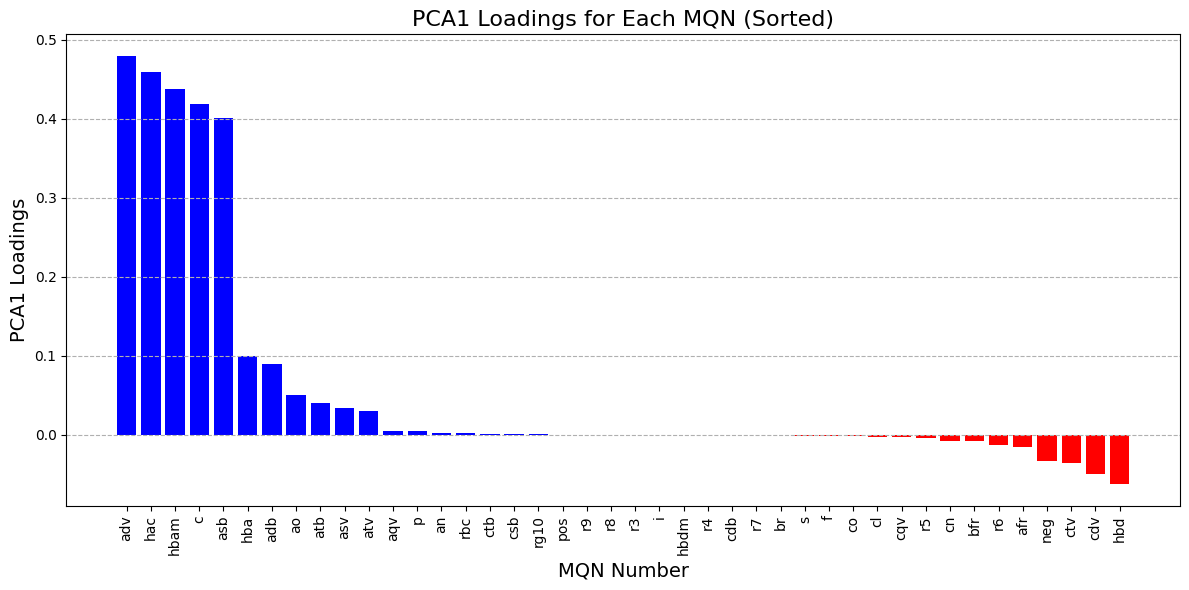

['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red']


In [4]:
# Create a list of column names for MQN data
mqn_columns = [
    "c", "f", "cl", "br", "i", "s", "p", "an", "cn", "ao", "co",
    "hac", "hbam", "hba", "hbdm", "hbd", "neg", "pos", "asb", "adb",
    "atb", "csb", "cdb", "ctb", "rbc", "asv", "adv", "atv", "aqv",
    "cdv", "ctv", "cqv", "r3", "r4", "r5", "r6", "r7", "r8", "r9",
    "rg10", "afr", "bfr"

]

mqn_pca_df = mqn_df.copy()
mqn_pca_df = mqn_pca_df[mqn_columns] #filter out g_ID column

##### Apply PCA #####
pca_mqn = PCA(n_components=2) # 2D PCA
principalComponents = pca_mqn.fit_transform(mqn_pca_df)
principalDf_mqn = pd.DataFrame(data=principalComponents, columns=["PCA1", "PCA2"], index=mqn_pca_df.index)
principalDf_mqn["CCS"] = c3s_df["ccs"]

# Adjust color range limits for better contrast
ccs_min = principalDf_mqn["CCS"].quantile(0.05)  # Set lower bound to the 5th percentile
ccs_max = principalDf_mqn["CCS"].quantile(0.95)  # Set upper bound to the 95th percentile

plt.figure(figsize=(6, 6))
plt.scatter(principalDf_mqn["PCA1"], principalDf_mqn["PCA2"], c=principalDf_mqn["CCS"], cmap="plasma", alpha=0.7, vmin=ccs_min, vmax=ccs_max)
plt.xlabel("PCA1", fontsize=14)
plt.ylabel("PCA2", fontsize=14)
plt.title("PCA of MQNs Colored by CCS Values", fontsize=16)
plt.colorbar(label="CCS")
plt.grid(True)
plt.show()

print("MQN Explained Variance Ratio:", pca_mqn.explained_variance_ratio_)
print("MQN Total Explained Variance:", sum(pca_mqn.explained_variance_ratio_))

loadings = pd.DataFrame(pca_mqn.components_, columns=mqn_columns, index=['PCA1', 'PCA2'])
pca1_loadings = loadings.loc['PCA1']  # Get PCA1 loadings (not absolute)
sorted_loadings = pca1_loadings.sort_values(ascending=False)

colors = ['red' if loading < 0 else 'blue' for loading in sorted_loadings]

plt.figure(figsize=(12, 6))
plt.bar(sorted_loadings.index, sorted_loadings.values, color=colors)
plt.xlabel("MQN Number", fontsize=14)
plt.ylabel("PCA1 Loadings", fontsize=14)
plt.title("PCA1 Loadings for Each MQN (Sorted)", fontsize=16)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--')  # Add a grid to the y-axis

plt.tight_layout()
plt.show()
print(colors)

## PCA on Fingerprints

In [5]:
fngr_df = fngr_df.drop(columns = ['g_id'])

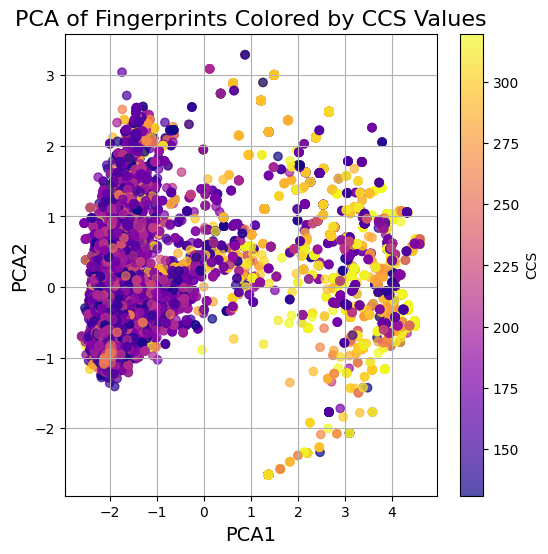

Fingerprint Explained Variance Ratio: [0.17717813 0.03812798]
Fingerprint Total Explained Variance: 0.2153061069446444


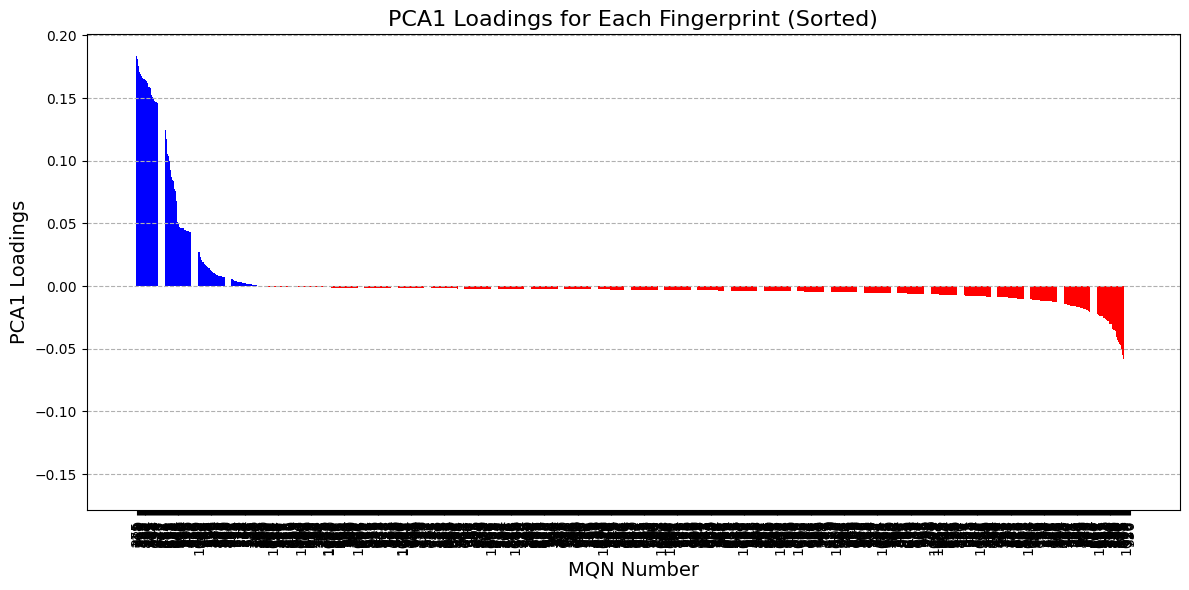

In [6]:
pca_finger = PCA(n_components=2)
principalComponents_finger = pca_finger.fit_transform(fngr_df)

principalDf_finger = pd.DataFrame(data=principalComponents_finger, columns=["PCA1", "PCA2"], index=fngr_df.index)
principalDf_finger["CCS"] = c3s_df["ccs"]  # Add CCS values for visualization

ccs_min = principalDf_finger["CCS"].quantile(0.05)  # Set lower bound to the 5th percentile
ccs_max = principalDf_finger["CCS"].quantile(0.95)  # Set upper bound to the 95th percentile

plt.figure(figsize=(6, 6))
plt.scatter(principalDf_finger["PCA1"], principalDf_finger["PCA2"], c=principalDf_finger["CCS"], cmap="plasma", alpha=0.7, vmin=ccs_min, vmax=ccs_max)
plt.xlabel("PCA1", fontsize=14)
plt.ylabel("PCA2", fontsize=14)
plt.title("PCA of Fingerprints Colored by CCS Values", fontsize=16)
plt.colorbar(label="CCS")
plt.grid(True)
plt.show()

# --- Print explained variance for Adducts ---
print("Fingerprint Explained Variance Ratio:", pca_finger.explained_variance_ratio_)
print("Fingerprint Total Explained Variance:", sum(pca_finger.explained_variance_ratio_))


loadings = pd.DataFrame(pca_finger.components_, columns=fngr_df.columns, index=['PCA1', 'PCA2'])
pca1_loadings = loadings.loc['PCA1']  # Get PCA1 loadings (not absolute)
sorted_loadings = pca1_loadings.sort_values(ascending=False)

colors = ['red' if loading < 0 else 'blue' for loading in sorted_loadings]

plt.figure(figsize=(12, 6))
plt.bar(sorted_loadings.index, sorted_loadings.values, color=colors)
plt.xlabel("MQN Number", fontsize=14)
plt.ylabel("PCA1 Loadings", fontsize=14)
plt.title("PCA1 Loadings for Each Fingerprint (Sorted)", fontsize=16)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--')  # Add a grid to the y-axis

plt.tight_layout()
plt.show()

# Fingerprint Clustering

In [8]:
# https://www.rdkit.org/docs/source/rdkit.Chem.Fingerprints.ClusterMols.html
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.DataStructs import BulkTanimotoSimilarity, FingerprintSimilarity
from rdkit.ML.Cluster import Butina
import matplotlib.pyplot as plt
from collections import defaultdict
from rdkit import DataStructs
from rdkit.DataStructs.cDataStructs import ExplicitBitVect

In [ ]:
# === Step 1: Cluster using Butina ===
def cluster_fingerprints(fps, cutoff=0.7):
    # Build distance matrix (1 - similarity)
    dists = []
    nfps = len(fps)
    for i in range(1, nfps):
        sims = BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])

    # Perform Butina clustering
    clusters = Butina.ClusterData(dists, nfps, cutoff, isDistData=True)
    return clusters

# === Step 2: Visualize clusters ===
# 3. Visualize clusters in 2D using PCA or t-SNE
def visualize_clusters_2d(df, clusters, method="pca"):
    X = df.to_numpy()

    if method == "pca":
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X)

    # Assign a cluster ID per row
    cluster_ids = np.zeros(len(df), dtype=int)
    for i, cluster in enumerate(clusters):
        for idx in cluster:
            cluster_ids[idx] = i

    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_ids, cmap='tab20', s=40)
    plt.title("Fingerprint Clusters ({} projection)".format(method.upper()))
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.colorbar(scatter, label="Cluster ID")
    plt.tight_layout()
    plt.show()

In [18]:
master_df = master_df.dropna()
print(fngr_df.shape)
print(master_df.shape)

(15187, 1024)
(15187, 12)


In [21]:
# - `mols`: a list of RDKit Mol objects
# - `fps`: a list of precomputed fingerprints for those mols

mols = []
for _, row in master_df[:50].iterrows():
    mols.append(Chem.MolFromSmiles(row['smi']))

fps = []
for _, row in fngr_df[:50].iterrows():
    bitvect = ExplicitBitVect(len(row))
    for i, bit in enumerate(row):
        if bit == 1:
            bitvect.SetBit(i)
    fps.append(bitvect)

In [ ]:
clusters = cluster_fingerprints(fps, cutoff=0.7)
visualize_clusters_2d(fngr_df, clusters, method="tsne")  # or "pca"


Cluster 1: 10 molecules
Cluster 2: 9 molecules
Cluster 3: 2 molecules
Cluster 4: 5 molecules
Cluster 5: 2 molecules
Cluster 6: 1 molecules
Cluster 7: 2 molecules
Cluster 8: 3 molecules
Cluster 9: 1 molecules
Cluster 10: 2 molecules
Cluster 11: 1 molecules
Cluster 12: 1 molecules
Cluster 13: 2 molecules
Cluster 14: 1 molecules
Cluster 15: 1 molecules
Cluster 16: 1 molecules
Cluster 17: 1 molecules
Cluster 18: 1 molecules
Cluster 19: 1 molecules
Cluster 20: 1 molecules
Cluster 21: 1 molecules
Cluster 22: 1 molecules
